In [1]:
import sys
!{sys.executable} -m pip install gymnasium

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from IPython.display import clear_output, display
import copy



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
print(env.action_space)
print(env.observation_space)
print(env.action_space.sample())

Discrete(3)
Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
1


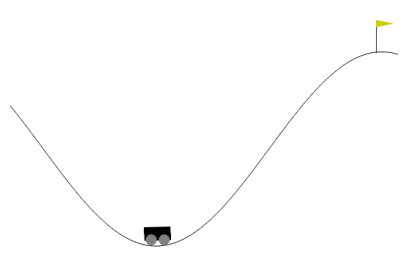

In [3]:
obs, info = env.reset()
done = False

for _ in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    clear_output(wait=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    time.sleep(0.01)
env.close()


# How mountain car act

In [4]:
obs, info = env.reset()

done = False
while not done:
   env.render()
   obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
   done = terminated or truncated
   print(f"{obs} -> {rew}")
   
env.close()

[-5.4854643e-01  1.8834154e-04] -> -1.0
[-0.5491712  -0.00062473] -> -1.0
[-5.4960430e-01 -4.3312053e-04] -> -1.0
[-0.5508426  -0.00123828] -> -1.0
[-0.5518768  -0.00103418] -> -1.0
[-0.5536991  -0.00182235] -> -1.0
[-0.554296  -0.0005969] -> -1.0
[-0.553663  0.000633] -> -1.0
[-0.5528048   0.00085818] -> -1.0
[-0.5517279   0.00107695] -> -1.0
[-0.5504402   0.00128766] -> -1.0
[-0.54895145  0.00148876] -> -1.0
[-0.54627275  0.00267872] -> -1.0
[-0.54342407  0.00284864] -> -1.0
[-0.54142684  0.00199724] -> -1.0
[-0.5382959   0.00313089] -> -1.0
[-0.53505486  0.00324108] -> -1.0
[-0.5327279   0.00232699] -> -1.0
[-0.53033245  0.00239545] -> -1.0
[-0.5288865   0.00144595] -> -1.0
[-0.52640086  0.0024856 ] -> -1.0
[-0.52289426  0.00350662] -> -1.0
[-0.5183929   0.00450133] -> -1.0
[-0.51493067  0.00346229] -> -1.0
[-0.5115334   0.00339729] -> -1.0
[-0.5072265   0.00430682] -> -1.0
[-0.50304246  0.00418408] -> -1.0
[-0.50001246  0.00303   ] -> -1.0
[-0.4981592   0.00185325] -> -1.0
[-0.4954

In [5]:
print(env.observation_space.low)
print(env.observation_space.high)

[-1.2  -0.07]
[0.6  0.07]


# State Discretization

In [6]:
def create_bins(i, num):
    # Same name as lesson: returns bin edges
    # num bins -> num+1 edges
    return np.arange(num + 1) * (i[1] - i[0]) / num + i[0]

# intervals from env bounds (MountainCar has 2 dims: pos, vel)
ints = [
    (float(env.observation_space.low[0]), float(env.observation_space.high[0])),  # position
    (float(env.observation_space.low[1]), float(env.observation_space.high[1]))   # velocity
]
nbins = [24, 18]

bins = [create_bins(ints[i], nbins[i]) for i in range(2)]

def discretize_bins(x):
    # Same idea as lesson, but for 2 dimensions
    # digitize returns 0..len(bins[i]) so we clamp into valid bin index range
    s0 = int(np.digitize(x[0], bins[0]) - 1)
    s1 = int(np.digitize(x[1], bins[1]) - 1)
    s0 = int(np.clip(s0, 0, nbins[0] - 1))
    s1 = int(np.clip(s1, 0, nbins[1] - 1))
    return (s0, s1)

# Q-Table Structure

In [7]:
Q = {}
actions = (0, 1, 2)

def qvalues(state):
    return [Q.get((state, a), 0.0) for a in actions]

# Kept from lesson (not required if using pure greedy)
def probs(v, eps=1e-4):
    v = v - v.min() + eps
    v = v / v.sum()
    return v

In [8]:
# hyperparameters

alpha = 0.1
gamma = 0.9
epsilon = 1.0

epsilon_min = 0.05
epsilon_decay = 0.9995

In [9]:
Qmax = -1e9
Qbest = copy.deepcopy(Q)

cum_rewards = []
rewards = []

for epoch in range(60000):
    obs, info = env.reset()
    done = False
    cum_reward = 0

    # == do the simulation ==
    while not done:
        s = discretize_bins(obs)

        if random.random() < epsilon:
            # exploration:
            a = np.random.randint(env.action_space.n)
        else:
            # exploitation:
            qs = qvalues(s)
            max_q = max(qs)
            best_actions = [a for a, q in zip(actions, qs) if q == max_q]
            a = random.choice(best_actions)

        obs, rew, terminated, truncated, info = env.step(a)
        done = terminated or truncated
        cum_reward += rew

        ns = discretize_bins(obs)

        Q[(s, a)] = (1 - alpha) * Q.get((s, a), 0.0) + alpha * (rew + gamma * max(qvalues(ns)))

    cum_rewards.append(cum_reward)
    rewards.append(cum_reward)

    # Decay epsilon (still "prob exploit" here)
    # This slowly reduces exploitation probability down to epsilon_min,
    # which means exploration increases later. That's NOT what we usually want,
    # but it matches lesson semantics. If you want the standard semantics,
    # we can flip the if/else and use epsilon as explore-prob.
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # == Periodically print results and calculate average reward ==
    if epoch % 2000 == 0 and epoch > 0:
        avg = float(np.average(cum_rewards))
        print(f"{epoch}: {avg:.2f}, alpha={alpha}, epsilon={epsilon:.3f}")
        if avg > Qmax:
            Qmax = avg
            Qbest = copy.deepcopy(Q)  # IMPORTANT: deepcopy
        cum_rewards = []

env.close()

2000: -199.99, alpha=0.1, epsilon=0.368
4000: -196.34, alpha=0.1, epsilon=0.135
6000: -182.54, alpha=0.1, epsilon=0.050
8000: -176.28, alpha=0.1, epsilon=0.050
10000: -172.19, alpha=0.1, epsilon=0.050
12000: -173.02, alpha=0.1, epsilon=0.050
14000: -173.32, alpha=0.1, epsilon=0.050
16000: -169.94, alpha=0.1, epsilon=0.050
18000: -175.36, alpha=0.1, epsilon=0.050
20000: -163.88, alpha=0.1, epsilon=0.050
22000: -172.82, alpha=0.1, epsilon=0.050
24000: -165.37, alpha=0.1, epsilon=0.050
26000: -163.43, alpha=0.1, epsilon=0.050
28000: -173.41, alpha=0.1, epsilon=0.050
30000: -169.18, alpha=0.1, epsilon=0.050
32000: -163.71, alpha=0.1, epsilon=0.050
34000: -169.86, alpha=0.1, epsilon=0.050
36000: -171.07, alpha=0.1, epsilon=0.050
38000: -169.58, alpha=0.1, epsilon=0.050
40000: -169.73, alpha=0.1, epsilon=0.050
42000: -169.00, alpha=0.1, epsilon=0.050
44000: -169.53, alpha=0.1, epsilon=0.050
46000: -173.30, alpha=0.1, epsilon=0.050
48000: -164.58, alpha=0.1, epsilon=0.050
50000: -169.60, alph

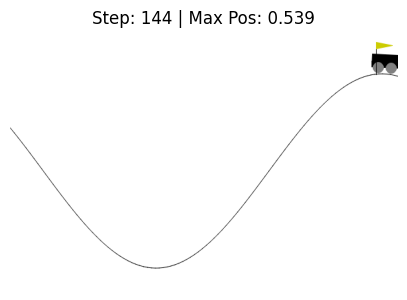

Total reward: -145.0
Max position reached: 0.53915435
Reached goal: True


In [12]:
# IMPORTANT: recreate env with render_mode="rgb_array"
env = gym.make("MountainCar-v0", render_mode="rgb_array")

obs, info = env.reset()
done = False
total_reward = 0
max_pos = -1e9
step = 0

while not done:
    # --- use trained Q-table instead of random ---
    s = discretize_bins(obs)  # your lesson-style discretizer

    qs = [Qbest.get((s, a), 0.0) for a in actions]  # use Qbest if saved
    max_q = max(qs)
    best_actions = [a for a, q in zip(actions, qs) if q == max_q]
    action = random.choice(best_actions)

    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    total_reward += reward
    max_pos = max(max_pos, obs[0])

    # --- render ---
    frame = env.render()
    clear_output(wait=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Step: {step} | Max Pos: {max_pos:.3f}")
    plt.show()

    time.sleep(0.01)
    step += 1

env.close()

print("Total reward:", total_reward)
print("Max position reached:", max_pos)
print("Reached goal:", terminated)

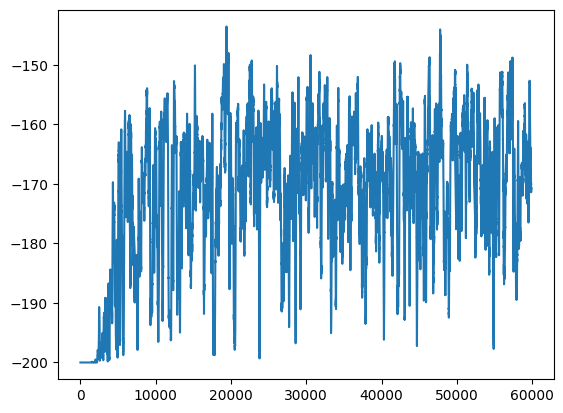

In [14]:
def running_average(x,window):
    return np.convolve(x,np.ones(window)/window,mode='valid')

plt.plot(running_average(rewards,100))